In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
with open("dataset_exercicio_3.csv", "r") as f:
    linhas = f.readlines()

dados = []
for linha in linhas:
    linha = linha.strip().strip('|')
    if '---' in linha:
        continue
    partes = [p.strip() for p in linha.split('|')]
    try:
        dados.append([float(p) for p in partes])
    except ValueError:
        continue

dataset = np.array(dados)

print(dataset)

[[ 0. 55.]
 [ 1. 58.]
 [ 2. 60.]
 [ 3. 63.]
 [ 4. 65.]
 [ 5. 68.]
 [ 6. 70.]
 [ 7. 72.]
 [ 8. 74.]
 [ 9. 76.]
 [10. 78.]
 [11. 80.]
 [12. 82.]
 [13. 83.]
 [14. 85.]
 [15. 86.]
 [16. 87.]
 [17. 88.]
 [18. 89.]
 [19. 90.]]


In [6]:
X = dataset[:, 0]
y = dataset[:, 1]
n = len(X)

print("X:", X)
print("y:", y)

print("\n Número de amostras: ", X.shape[0])

X: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]
y: [55. 58. 60. 63. 65. 68. 70. 72. 74. 76. 78. 80. 82. 83. 85. 86. 87. 88.
 89. 90.]

 Número de amostras:  20


Média de X: 9.5
Média de y: 75.45

Intercepto (a): 57.8143
Inclinação (b): 1.8564

Valores previstos: [57.81428571 59.67067669 61.52706767 63.38345865 65.23984962 67.0962406
 68.95263158 70.80902256 72.66541353 74.52180451 76.37819549 78.23458647
 80.09097744 81.94736842 83.8037594  85.66015038 87.51654135 89.37293233
 91.22932331 93.08571429]

Cálculo do Coeficiente de Pearson: 0.9894

Cálculo de Determinação: 97.8968


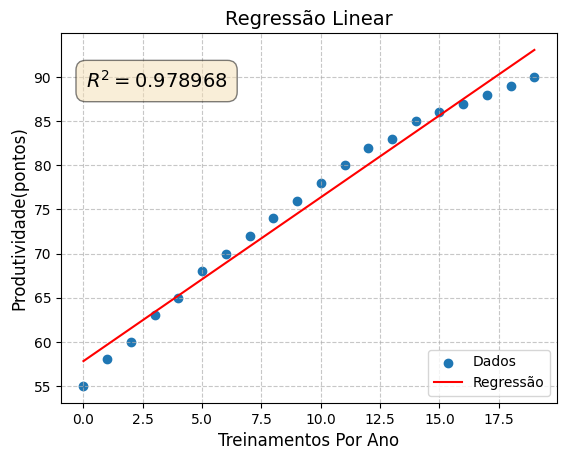

In [7]:
x_mean = np.mean(X)
y_mean = np.mean(y)

print("Média de X:", x_mean)
print("Média de y:", y_mean)

b, a = np.polyfit(X, y, 1)
print(f"\nIntercepto (a): {a:.4f}")
print(f"Inclinação (b): {b:.4f}")

y_pred = a + b * X
print(f"\nValores previstos: {y_pred}")

coef_pearson = np.corrcoef(X, y)[0, 1]
print(f"\nCálculo do Coeficiente de Pearson: {coef_pearson:.4f}")

det_quadrado = coef_pearson ** 2
print(f"\nCálculo de Determinação: {det_quadrado * 100:.4f}")

plt.scatter(X, y, label="Dados")
plt.plot(X, y_pred, color="red", label="Regressão")
plt.title("Regressão Linear", fontsize=14)
plt.xlabel("Treinamentos Por Ano", fontsize=12)
plt.ylabel("Produtividade(pontos)", fontsize=12)
plt.text(0.05, 0.9, f'$R^2 = {det_quadrado:4f}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### a- O gráfico sugere que existe uma relação linear clara entre a quantidade de treinamentos e a produtividade?

R: Sim, o gráfico indica uma relação linear positiva entre a quantidade de treinamentos e a produtividade. Observa-se uma tendência crescente, sugerindo que, em geral, quanto mais treinamentos o funcionário realiza, maior tende a ser sua produtividade.

### b- Qual é a interpretação do coeficiente angular neste caso? (quanto a produtividade aumenta, em média, a cada treinamento realizado).

R: O coeficiente angular representa o aumento médio da produtividade para cada treinamento adicional realizado. Ou seja, indica quantos pontos de produtividade, em média, são ganhos a cada novo treinamento.

### c- Qual seria a produtividade prevista para um funcionário que participou de 20 treinamentos?

R: A produtividade prevista pode ser calculada utilizando a equação da reta y=a+bx, substituindo x=20. Usando a equação da reta y=a+bx:

y=57.8143+1.8564×20
y=57.8143+37.128
y≈94.9423

R: A produtividade prevista é aproximadamente 94,94 pontos.

### d- Se um funcionário não fez nenhum treinamento no ano, o modelo prevê uma produtividade inicial de quanto? Essa previsão parece realista?

R: Nesse caso, a produtividade prevista é igual ao intercepto a, pois x=0. Assim:

y=57.8143+1.8564×0=57.8143

Portanto, a produtividade inicial prevista é de aproximadamente 57,81 pontos. Esse valor representa a produtividade base na ausência de treinamentos. No entanto, essa estimativa pode não ser totalmente realista, uma vez que a produtividade também é influenciada por diversos outros fatores além da quantidade de treinamentos realizados.

### e- O ganho de produtividade continua indefinidamente com mais treinamentos, ou há sinais de que ele tende a se estabilizar?

R: Embora o modelo linear sugira crescimento contínuo, na prática é esperado que o ganho de produtividade tenda a se estabilizar após certo número de treinamentos, devido a efeitos como saturação de aprendizado ou limitações humanas.

### f- Se a empresa tivesse que escolher entre oferecer 5 ou 15 treinamentos por ano, qual seria a diferença prevista de produtividade? Essa diferença justificaria o investimento?

R: A diferença prevista de produtividade pode ser calculada pela inclinação da reta multiplicada pela diferença no número de treinamentos:

Δy=b×(15−5)=1,8564×10=18,564

Assim, o ganho adicional esperado é de aproximadamente 18,56 pontos de produtividade ao passar de 5 para 15 treinamentos. No entanto, essa diferença, por si só, não garante que o investimento seja justificável, sendo necessário avaliar também os custos dos treinamentos e o retorno financeiro gerado pelo aumento da produtividade.

### g- Quais outras variáveis poderiam influenciar a produtividade além da quantidade de treinamentos?

R: A produtividade pode ser influenciada por diversos outros fatores, como experiência profissional, motivação, ambiente de trabalho, qualidade dos treinamentos, nível de escolaridade, habilidades individuais, liderança, cultura organizacional e condições de trabalho.